# 开始使用

data-notebook 的示例使用项目本地数据目录 `data/` 中的数据文件，不直接访问 CMADAAS 挂载点。本节介绍：

- 如何使用 `data-notebook` 命令将 CMADAAS 业务系统数据拷贝到本地数据目录；
- 如何使用 reki 加载已下载的 GRIB2 数据。

## 拷贝系统数据

### 本地数据目录

数据按系统分目录保存在项目根目录的 `data/` 目录下，每个系统目录中的 `metadata.yaml` 记录了数据文件信息（起报时次、预报时效、文件列表等）：

```text
data/
├── cma-gfs/
│   ├── metadata.yaml
│   └── grib2/orig/Z_NAFP_C_BABJ_..._02400.grib2
└── cma-meso-1km/
    ├── metadata.yaml
    └── grib2/orig/Z_NAFP_C_BABJ_..._02400.grb2
```

目前支持的系统：

| 系统标识 | 说明 |
|----------|------|
| `cma-gfs` | CMA-GFS 全球模式原始分辨率 GRIB2 产品 |
| `cma-meso-1km` | CMA-MESO 1km 区域模式 GRIB2 产品 |

### 下载数据

数据下载为手动操作，需要在挂载了 CMADAAS（如 `/CMADAAS`）的环境中执行。下载命令使用 reki 的 `find_local_file` 在 CMADAAS 目录中定位文件，拷贝到本地 `data/<system>/` 目录，并生成 `metadata.yaml`。

```bash
# 下载 CMA-GFS 数据（默认：当前 UTC 时间前 2 天的 00 时起报，24h 时效）
uv run data-notebook data download cma-gfs

# 下载 CMA-MESO 1km 数据
uv run data-notebook data download cma-meso-1km
```

常用选项：

```bash
# 指定起报时次（YYYYMMDDHH）和预报时效
uv run data-notebook data download cma-gfs --start-time 2026072500 --forecast-time 24h

# 指定 CMADAAS 挂载点（默认 /CMADAAS）
uv run data-notebook data download cma-gfs --storage-base /path/to/cmadaas

# 覆盖已存在的本地文件
uv run data-notebook data download cma-gfs --force
```

查看已下载的数据：

```bash
uv run data-notebook data list
```

```{tip}
数据根目录默认为项目根目录下的 `data/`，可用环境变量 `DATA_NOTEBOOK_DATA_ROOT` 覆盖。
```

## 本地数据文件

Notebook 通过 `data_notebook.data` 模块访问本地数据。

获取本地数据根目录：

In [1]:
from data_notebook.data import get_data_root

data_root = get_data_root()
data_root

PosixPath('/home/wangdp/project/cedarkit/notebook-project/notebook-devel/ref/data-notebook-project/data-notebook/data')

`load_metadata` 函数读取系统目录中的 `metadata.yaml`，返回起报时次、预报时效和文件列表等数据信息：

In [2]:
from data_notebook.data import load_metadata

metadata = load_metadata("cma-gfs")
metadata

{'system': 'cma-gfs',
 'description': 'CMA-GFS 全球模式原始分辨率 GRIB2 产品',
 'data_type': 'cma_gfs_gmf/grib2/orig',
 'source': {'data_class': 'cmadaas', 'storage_base': '/CMADAAS'},
 'query': {'start_time': '2026072500', 'forecast_time': '24h'},
 'downloaded_at': '2026-07-27T06:46:09+00:00',
 'files': [{'path': 'grib2/orig/Z_NAFP_C_BABJ_20260725000000_P_NWPC-GRAPES-GFS-GLB-02400.grib2',
   'source_path': '/CMADAAS/DATA/NAFP/NMC/GRAPES-GFS-GLB/2026/20260725/Z_NAFP_C_BABJ_20260725000000_P_NWPC-GRAPES-GFS-GLB-02400.grib2',
   'size': 1523461412}]}

`get_data_file` 函数从 `metadata.yaml` 中获取数据文件的绝对路径。下面示例获取 CMA-GFS 系统原始分辨率 GRIB2 文件的本地路径：

In [3]:
from data_notebook.data import get_data_file

gfs_grib2_file_path = get_data_file("cma-gfs")
gfs_grib2_file_path

PosixPath('/home/wangdp/project/cedarkit/notebook-project/notebook-devel/ref/data-notebook-project/data-notebook/data/cma-gfs/grib2/orig/Z_NAFP_C_BABJ_20260725000000_P_NWPC-GRAPES-GFS-GLB-02400.grib2')

## 使用 reki 加载 GRIB2 数据

reki 使用 ecCodes 从 GRIB2 文件中检索要素场，并返回 `xarray.DataArray` 对象。

下面示例从已下载的 CMA-GFS GRIB2 产品文件中加载 850hPa 温度场。其中：

- `parameter` 参数表示要素名称，`t` 代表温度
- `level_type` 参数表示层次类型，`pl` 代表等压面层，单位 hPa
- `level` 参数表示层次值

In [4]:
from reki.format.grib.eccodes import load_field_from_file

field = load_field_from_file(
    gfs_grib2_file_path,
    parameter="t",
    level_type="pl",
    level=850,
    lazy=True
)
field

/home/wangdp/project/cedarkit/notebook-project/notebook-devel/ref/data-notebook-project/data-notebook/.venv/lib/python3.14/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.42.0 or higher is recommended. You are running version 2.34.1
  warnings.warn(


<xarray.DataArray 't' (latitude: 1440, longitude: 2880)> Size: 33MB
[4147200 values with dtype=float64]
Coordinates:
  * latitude    (latitude) float64 12kB 89.94 89.81 89.69 ... -89.81 -89.94
  * longitude   (longitude) float64 23kB 0.0 0.125 0.25 ... 359.6 359.8 359.9
    time        datetime64[us] 8B 2026-07-25
    step        timedelta64[us] 8B 1 days
    valid_time  datetime64[us] 8B 2026-07-26
    pl          float64 8B 850.0
Attributes: (12/24)
    GRIB_edition:                         2
    GRIB_centre:                          babj
    GRIB_subCentre:                       0
    GRIB_tablesVersion:                   4
    GRIB_localTablesVersion:              0
    GRIB_dataType:                        fc
    ...                                   ...
    GRIB_parameterCategory:               0
    GRIB_parameterNumber:                 0
    long_name:                            Temperature
    cemc_name:                            t
    eccodes_name:                         t
    wgrib2_name:                          TMP

可以使用 xarray 提供的一系列功能对要素场进行分析。比如使用 `xarray.DataArray.plot()` 函数实现快速绘图：

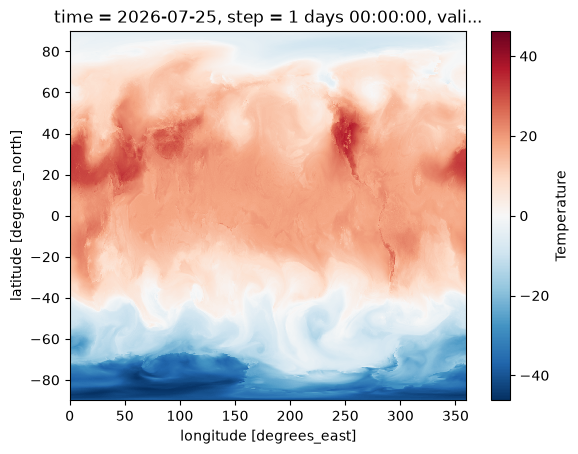

In [5]:
(field - 273.15).plot()

### 加载区域模式数据

同样的方法也适用于其他系统已下载的数据。下面示例从 CMA-MESO 1km 的 GRIB2 文件中加载 2 米温度场，其中 `heightAboveGround` 表示距地面高度层，单位米：

In [6]:
meso_grib2_file_path = get_data_file("cma-meso-1km")

meso_field = load_field_from_file(
    meso_grib2_file_path,
    parameter="t",
    level_type="heightAboveGround",
    level=2,
    lazy=True
)
meso_field

<xarray.DataArray 't' (latitude: 5011, longitude: 7501)> Size: 301MB
[37587511 values with dtype=float64]
Coordinates:
  * latitude           (latitude) float64 40kB 60.1 60.09 60.08 ... 10.01 10.0
  * longitude          (longitude) float64 60kB 70.0 70.01 70.02 ... 145.0 145.0
    time               datetime64[us] 8B 2026-07-25
    step               timedelta64[us] 8B 1 days
    valid_time         datetime64[us] 8B 2026-07-26
    heightAboveGround  int64 8B 2
Attributes: (12/24)
    GRIB_edition:                         2
    GRIB_centre:                          babj
    GRIB_subCentre:                       0
    GRIB_tablesVersion:                   4
    GRIB_localTablesVersion:              0
    GRIB_dataType:                        fc
    ...                                   ...
    GRIB_parameterCategory:               0
    GRIB_parameterNumber:                 0
    long_name:                            2 metre temperature
    cemc_name:                            t2m
    eccodes_name:                         2t
    wgrib2_name:                          TMP

同样可以使用 `xarray.DataArray.plot()` 快速查看要素场分布：

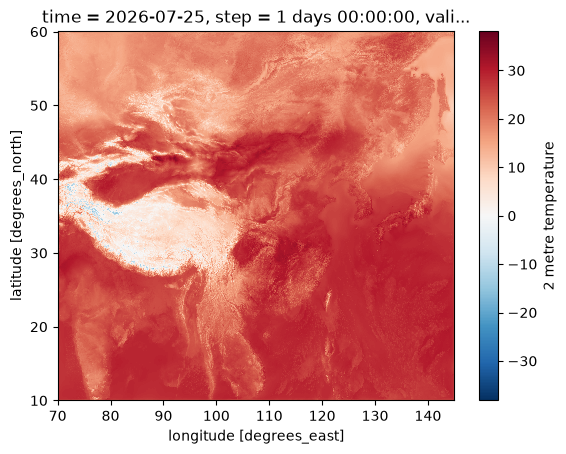

In [7]:
(meso_field - 273.15).plot()